In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Loading Dataset
file_path = "/content/drive/MyDrive/NVD_Cybersecurity_Dataset.csv"
df = pd.read_csv(file_path)

print(df.shape)
print(df.columns.tolist())
df.head()

(337705, 19)
['CVE_ID', 'Published_Date', 'Publish_Year', 'Publish_Month', 'Description', 'Clean_Description', 'Word_Count', 'Char_Length', 'Flag_XSS', 'Flag_SQLi', 'Flag_Buffer_Overflow', 'Flag_RCE', 'Flag_Privilege_Escalation', 'Flag_DoS', 'Flag_Directory_Traversal', 'CVSS_Base_Score', 'Severity', 'Exploitability_Score', 'Impact_Score']


,CVE_ID,Published_Date,Publish_Year,Publish_Month,Description,Clean_Description,Word_Count,Char_Length,Flag_XSS,Flag_SQLi,Flag_Buffer_Overflow,Flag_RCE,Flag_Privilege_Escalation,Flag_DoS,Flag_Directory_Traversal,CVSS_Base_Score,Severity,Exploitability_Score,Impact_Score
0,CVE-1999-0095,1988-10-01,1988,10,"The debug command in Sendmail is enabled, allo...","the debug command in sendmail is enabled, allo...",14,89,0,0,0,0,0,0,0,10.0,HIGH,10.0,10.0
1,CVE-1999-0082,1988-11-11,1988,11,CWD ~root command in ftpd allows root access.,cwd ~root command in ftpd allows root access.,8,45,0,0,0,0,0,0,0,10.0,HIGH,10.0,10.0
2,CVE-1999-1471,1989-01-01,1989,1,Buffer overflow in passwd in BSD based operati...,buffer overflow in passwd in bsd based operati...,27,158,0,0,1,0,0,0,0,7.2,HIGH,3.9,10.0
3,CVE-1999-1122,1989-07-26,1989,7,Vulnerability in restore in SunOS 4.0.3 and ea...,vulnerability in restore in sunos 4.0.3 and ea...,14,90,0,0,0,0,0,0,0,4.6,MEDIUM,3.9,6.4
4,CVE-1999-1467,1989-10-26,1989,10,Vulnerability in rcp on SunOS 4.0.x allows rem...,vulnerability in rcp on sunos 4.0.x allows rem...,27,175,0,0,0,0,0,0,0,10.0,HIGH,10.0,10.0


In [4]:
USE_SAMPLE = True
SAMPLE_SIZE = 120000

if USE_SAMPLE and len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print("Working shape:", df.shape)

Working shape: (120000, 19)


In [5]:
#Check missing values and target
print(df.isnull().sum())
print("\nTarget summary:")
print(df["CVSS_Base_Score"].describe())

CVE_ID                       0
Published_Date               0
Publish_Year                 0
Publish_Month                0
Description                  0
Clean_Description            0
Word_Count                   0
Char_Length                  0
Flag_XSS                     0
Flag_SQLi                    0
Flag_Buffer_Overflow         0
Flag_RCE                     0
Flag_Privilege_Escalation    0
Flag_DoS                     0
Flag_Directory_Traversal     0
CVSS_Base_Score              0
Severity                     0
Exploitability_Score         0
Impact_Score                 0
dtype: int64

Target summary:
count    120000.000000
mean          6.322906
std           2.419744
min           0.000000
25%           5.300000
50%           6.500000
75%           7.800000
max          10.000000
Name: CVSS_Base_Score, dtype: float64


In [6]:
#Define features, target, and excluded columns
target = "CVSS_Base_Score"
text_col = "Clean_Description"

numeric_cols = [
    "Publish_Year",
    "Publish_Month",
    "Word_Count",
    "Char_Length",
    "Flag_XSS",
    "Flag_SQLi",
    "Flag_Buffer_Overflow",
    "Flag_RCE",
    "Flag_Privilege_Escalation",
    "Flag_DoS",
    "Flag_Directory_Traversal"
]

excluded_cols = [
    "CVE_ID",                # identifier only
    "Published_Date",        # redundant because year/month already exist
    "Description",           # raw text; cleaned text is better
    "Severity",              # related to target -> leakage risk
    "Exploitability_Score",  # too close to target -> leakage risk
    "Impact_Score"           # too close to target -> leakage risk
]

print("Using features:")
print([text_col] + numeric_cols)

print("\nExcluded columns:")
print(excluded_cols)

X = df[[text_col] + numeric_cols].copy()
y = df[target].copy()

Using features:
['Clean_Description', 'Publish_Year', 'Publish_Month', 'Word_Count', 'Char_Length', 'Flag_XSS', 'Flag_SQLi', 'Flag_Buffer_Overflow', 'Flag_RCE', 'Flag_Privilege_Escalation', 'Flag_DoS', 'Flag_Directory_Traversal']

Excluded columns:
['CVE_ID', 'Published_Date', 'Description', 'Severity', 'Exploitability_Score', 'Impact_Score']


In [7]:
#Train/test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (96000, 12)
X_test : (24000, 12)


Preprocessing

In [8]:
text_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=3000,
        min_df=5,
        stop_words="english",
        ngram_range=(1, 2)
    )),
    ("svd", TruncatedSVD(n_components=100, random_state=42))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("text", text_pipeline, text_col),
    ("num", numeric_pipeline, numeric_cols)
])

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

print("Preprocessed train shape:", X_train_p.shape)
print("Preprocessed test shape :", X_test_p.shape)
print("Type:", type(X_train_p))

Preprocessed train shape: (96000, 111)
Preprocessed test shape : (24000, 111)
Type: <class 'numpy.ndarray'>


In [9]:
#Metric Function
#1. MAE — Mean Absolute Error
#2. RMSE — Root Mean Squared Error
#3. R² — R-squared
#4. MSE - Mean Squared Error

def get_regression_metrics(y_true, y_pred, model_name, stage):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "Model": model_name,
        "Stage": stage,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred)
    }

Model Training


In [10]:
#Baseline ML Models
results = []
trained_baseline_models = {}

baseline_models = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": HistGradientBoostingRegressor(
        learning_rate=0.1,
        max_iter=200,
        random_state=42
    )
}

for name, model in baseline_models.items():
    print(f"Training baseline: {name}")
    model.fit(X_train_p, y_train)
    y_pred = model.predict(X_test_p)

    trained_baseline_models[name] = model
    results.append(get_regression_metrics(y_test, y_pred, name, "Baseline"))

baseline_results_df = pd.DataFrame(results).sort_values("RMSE")
baseline_results_df

Training baseline: Ridge
Training baseline: Random Forest
Training baseline: Gradient Boosting


,Model,Stage,MAE,MSE,RMSE,R2
1,Random Forest,Baseline,0.902409,1.856107,1.362390,0.681605
2,Gradient Boosting,Baseline,0.975260,1.990439,1.410829,0.658562
0,Ridge,Baseline,1.175176,2.604485,1.613842,0.553229


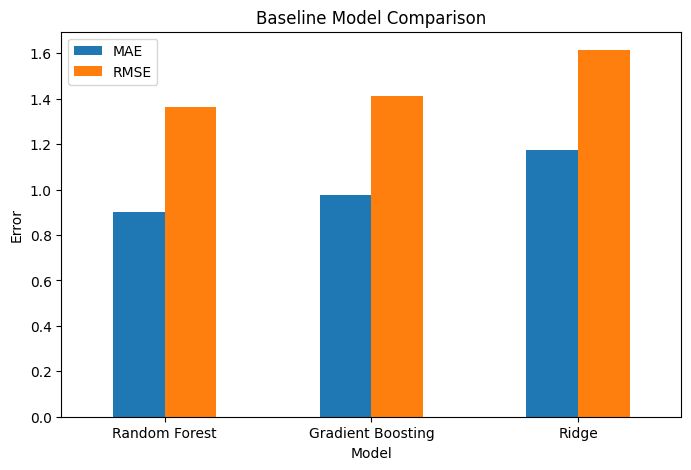

In [11]:
#Baseline comparison plot
baseline_plot = baseline_results_df.set_index("Model")[["MAE", "RMSE"]]
baseline_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Baseline Model Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#Hyperparameter tuning
best_params = {}
tuned_models = {}

ridge_search = GridSearchCV(
    estimator=Ridge(),
    param_grid={
        "alpha": [0.01, 0.1, 1, 10, 50, 100]
    },
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions={
        "n_estimators": [100, 150, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gbr_search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_distributions={
        "learning_rate": [0.03, 0.05, 0.1],
        "max_iter": [200, 300, 400],
        "max_depth": [None, 8, 12],
        "min_samples_leaf": [20, 50, 100]
    },
    n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

searches = {
    "Ridge": ridge_search,
    "Random Forest": rf_search,
    "Gradient Boosting": gbr_search
}

for name, search in searches.items():
    print(f"Tuning: {name}")
    search.fit(X_train_p, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_p)

    tuned_models[name] = best_model
    best_params[name] = search.best_params_
    results.append(get_regression_metrics(y_test, y_pred, name, "Tuned"))

print(best_params)

Tuning: Ridge
Tuning: Random Forest
Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [ ]:
#ML results table: baseline vs tuned
results_df = pd.DataFrame(results)

ml_results_df = results_df[results_df["Model"].isin(["Ridge", "Random Forest", "Gradient Boosting"])]
ml_results_df = ml_results_df.sort_values(["Model", "Stage"])

ml_results_df

In [ ]:
#Pivot table for presentation
ml_comparison_table = ml_results_df.pivot(
    index="Model",
    columns="Stage",
    values=["MAE", "MSE", "RMSE", "R2"]
).round(4)

ml_comparison_table

In [ ]:
#Improvement table
baseline_only = ml_results_df[ml_results_df["Stage"] == "Baseline"].set_index("Model")
tuned_only = ml_results_df[ml_results_df["Stage"] == "Tuned"].set_index("Model")

improvement_df = pd.DataFrame({
    "MAE_Change": tuned_only["MAE"] - baseline_only["MAE"],
    "MSE_Change": tuned_only["MSE"] - baseline_only["MSE"],
    "RMSE_Change": tuned_only["RMSE"] - baseline_only["RMSE"],
    "R2_Change": tuned_only["R2"] - baseline_only["R2"]
}).round(4)

improvement_df

Deep Learning Model Training

In [ ]:
#Prepare data for deep learning
X_train_dl = X_train_p.astype(np.float32)
X_test_dl = X_test_p.astype(np.float32)

y_train_dl = y_train.astype(np.float32).values
y_test_dl = y_test.astype(np.float32).values

print(X_train_dl.shape, X_test_dl.shape)

In [ ]:
#Build a Keras MLP function
def build_mlp(input_dim, hidden_layers=(128, 64), dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )
    return model

In [ ]:
#Baseline DL model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

dl_baseline = build_mlp(
    input_dim=X_train_dl.shape[1],
    hidden_layers=(128, 64),
    dropout_rate=0.2,
    learning_rate=0.001
)

history_baseline = dl_baseline.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.1,
    epochs=25,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

dl_baseline_pred = dl_baseline.predict(X_test_dl).ravel()
results.append(get_regression_metrics(y_test_dl, dl_baseline_pred, "Deep Learning (MLP)", "Baseline"))

In [ ]:
#Tuned DL model
dl_tuned = build_mlp(
    input_dim=X_train_dl.shape[1],
    hidden_layers=(256, 128, 32),
    dropout_rate=0.3,
    learning_rate=0.0005
)

history_tuned = dl_tuned.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.1,
    epochs=40,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

dl_tuned_pred = dl_tuned.predict(X_test_dl).ravel()
results.append(get_regression_metrics(y_test_dl, dl_tuned_pred, "Deep Learning (MLP)", "Tuned"))

In [ ]:
#Final full comparison table
final_results_df = pd.DataFrame(results).sort_values(["Model", "Stage"])
final_results_df.round(4)

In [ ]:
#Final pivot table for slides
final_comparison_table = final_results_df.pivot(
    index="Model",
    columns="Stage",
    values=["MAE", "MSE", "RMSE", "R2"]
).round(4)

final_comparison_table

Results

In [ ]:
#Save results to CSV
final_results_df.to_csv("final_model_results.csv", index=False)
final_comparison_table.to_csv("final_comparison_table.csv")

print("Saved: final_model_results.csv")
print("Saved: final_comparison_table.csv")

In [ ]:
# Create folder and  helper function to save tables as images
import os
import math
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create result folders
RESULT_DIR = "project_results"
TABLE_DIR = os.path.join(RESULT_DIR, "tables")
PLOT_DIR = os.path.join(RESULT_DIR, "plots")
CSV_DIR = os.path.join(RESULT_DIR, "csv")

for folder in [RESULT_DIR, TABLE_DIR, PLOT_DIR, CSV_DIR]:
    os.makedirs(folder, exist_ok=True)

def flatten_columns(df):
    """Flatten MultiIndex columns for cleaner table images."""
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [" | ".join([str(i) for i in col if str(i) != ""]) for col in df.columns.values]
    return df

def save_dataframe_as_image(df, filename, title=None, folder=TABLE_DIR, dpi=200):
    """
    Save a pandas DataFrame as a PNG image using matplotlib.
    """
    df_to_save = flatten_columns(df).copy()

    # Round float columns for prettier display
    for col in df_to_save.columns:
        if pd.api.types.is_numeric_dtype(df_to_save[col]):
            df_to_save[col] = df_to_save[col].round(4)

    # Convert index into a column if index has a useful name
    if df_to_save.index.name is not None or not isinstance(df_to_save.index, pd.RangeIndex):
        df_to_save = df_to_save.reset_index()

    nrows, ncols = df_to_save.shape

    fig_width = max(10, ncols * 2.2)
    fig_height = max(2.5, nrows * 0.5 + 1.5)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df_to_save.values,
        colLabels=df_to_save.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)

    if title:
        plt.title(title, fontsize=14, pad=20)

    save_path = os.path.join(folder, filename)
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.close()

    print(f"Saved table image: {save_path}")

In [ ]:
# Save your result tables as CSV and PNG
table_objects = {
    "baseline_results_df": globals().get("baseline_results_df"),
    "ml_results_df": globals().get("ml_results_df"),
    "ml_comparison_table": globals().get("ml_comparison_table"),
    "improvement_df": globals().get("improvement_df"),
    "final_results_df": globals().get("final_results_df"),
    "final_comparison_table": globals().get("final_comparison_table"),
}

for name, obj in table_objects.items():
    if obj is not None:
        # Save CSV
        csv_path = os.path.join(CSV_DIR, f"{name}.csv")
        obj.to_csv(csv_path)
        print(f"Saved CSV: {csv_path}")

        # Save PNG table
        save_dataframe_as_image(
            obj,
            filename=f"{name}.png",
            title=name.replace("_", " ").title()
        )

In [ ]:
#Save baseline comparison plot
if "baseline_results_df" in globals():
    plt.figure(figsize=(8, 5))
    baseline_plot_df = baseline_results_df.set_index("Model")[["MAE", "RMSE"]]
    baseline_plot_df.plot(kind="bar", figsize=(8, 5))
    plt.title("Baseline Model Comparison")
    plt.ylabel("Error")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "baseline_model_comparison.png"), dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved plot: baseline_model_comparison.png")

In [ ]:
#Save tuned vs baseline RMSE plot
if "final_results_df" in globals():
    plot_df = final_results_df.copy()

    plt.figure(figsize=(10, 5))
    for stage in plot_df["Stage"].unique():
        temp = plot_df[plot_df["Stage"] == stage]
        plt.bar(
            temp["Model"] + " (" + stage + ")",
            temp["RMSE"]
        )

    plt.title("RMSE by Model and Stage")
    plt.ylabel("RMSE")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "rmse_by_model_and_stage.png"), dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved plot: rmse_by_model_and_stage.png")

In [ ]:
# Save deep learning training curves
def save_training_history(history, filename_prefix):
    if history is None:
        return

    hist = history.history

    # Loss plot
    if "loss" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(hist["loss"], label="Train Loss")
        if "val_loss" in hist:
            plt.plot(hist["val_loss"], label="Validation Loss")
        plt.title(f"{filename_prefix} Loss Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, f"{filename_prefix}_loss_curve.png"), dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"Saved plot: {filename_prefix}_loss_curve.png")

    # MAE plot
    if "mae" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(hist["mae"], label="Train MAE")
        if "val_mae" in hist:
            plt.plot(hist["val_mae"], label="Validation MAE")
        plt.title(f"{filename_prefix} MAE Curve")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, f"{filename_prefix}_mae_curve.png"), dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"Saved plot: {filename_prefix}_mae_curve.png")

# Save baseline/tuned DL curves if histories exist
if "history_baseline" in globals():
    save_training_history(history_baseline, "dl_baseline")

if "history_tuned" in globals():
    save_training_history(history_tuned, "dl_tuned")

In [ ]:
#Save a summary text file
summary_lines = []

if "best_params" in globals():
    summary_lines.append("Best Hyperparameters\n")
    for model_name, params in best_params.items():
        summary_lines.append(f"{model_name}: {params}\n")

summary_lines.append("\nIncluded files:\n")
summary_lines.append("- CSV result tables\n")
summary_lines.append("- PNG table images\n")
summary_lines.append("- PNG plots\n")

summary_path = os.path.join(RESULT_DIR, "summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.writelines(summary_lines)

print(f"Saved summary: {summary_path}")

In [ ]:
zip_path = "project_results.zip"

# Remove old zip if it exists
if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive("project_results", "zip", RESULT_DIR)

print(f"ZIP created: {zip_path}")

In [ ]:
from google.colab import files
files.download("project_results.zip")